<a href="https://colab.research.google.com/github/AmanuelDaget/GBPUSD-Foreign-Exchange-Price-Pridiction-Using-LSTM-GRU-BiLSTM/blob/main/GBPUSD_Price_pridiction_Using_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GBPUSD Price pridiction Using LSTM GRU**

**Environment Setup & Installations**

In [1]:
pip install yfinance seaborn plotly

**Import Libraries**

In [2]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

**CONFIGURATION**

In [28]:
DATA_PATH     = "data/gbpusd_hourly_newyorkTimezone.csv"   # your downloaded CSV
MODELS_DIR    = "models"
PLOTS_DIR     = "plots"

LOOKBACK      = 24       # hours of past data used per input sample
TRAIN_RATIO   = 0.70     # 70 % train
VAL_RATIO     = 0.15     # 15 % validation  →  remaining 15 % = test
BATCH_SIZE    = 64
EPOCHS        = 50      # EarlyStopping will stop training early
PATIENCE      = 15       # epochs with no improvement before stopping
UNITS         = 64       # recurrent units per layer
DROPOUT       = 0.20     # dropout regularisation rate
LEARNING_RATE = 0.001    # Adam initial learning rate

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

print("=" * 70)
print("  GBP/USD Trend Prediction — RNN | LSTM | GRU | BiLSTM")
print("=" * 70)

  GBP/USD Trend Prediction — RNN | LSTM | GRU | BiLSTM


**Load the data**

In [4]:
print("\n[STEP 1]  Loading data ...")
print(f"  Source: {DATA_PATH}")

def load_csv_robust(path: str) -> pd.DataFrame:
    """
    Robustly loads a yfinance CSV with any of these header structures:

    Structure A (3-row header — your file):
        Row 0:  Price,    Open,     High,     Low,     Close
        Row 1:  Ticker,   GBPUSD=X, GBPUSD=X, GBPUSD=X, GBPUSD=X
        Row 2:  Datetime, <values>
        Row 3+: data

    Structure B (2-row header):
        Row 0:  Open,  High,  Low,  Close
        Row 1:  Ticker, GBPUSD=X ...
        Row 2+: data

    Structure C (1-row header — clean CSV):
        Row 0:  Datetime, Open, High, Low, Close
        Row 1+: data

    Strategy:
      - Read the file as raw strings with no parsing.
      - Find every row whose first cell is a datetime string.
      - The first such row is where data begins.
      - Scan ALL header rows above it and pick the one that contains
        the OHLC keywords (Open / High / Low / Close) as the column source.
      - Flatten any ticker suffixes, keep only OHLC.
    """
    raw = pd.read_csv(path, header=None, dtype=str)

    # ── 1. Find first data row (first cell parseable as datetime) ────────────
    data_start_row = None
    for i, val in enumerate(raw.iloc[:, 0]):
        v = str(val).strip()
        try:
            ts = pd.to_datetime(v)
            # Extra guard: reject obvious non-dates like "Price", "Ticker", "Datetime"
            if v.lower() not in {"price", "ticker", "datetime", "date", ""}:
                data_start_row = i
                break
        except Exception:
            continue

    if data_start_row is None:
        raise ValueError(
            "No datetime rows found in the first column. "            "Check that your CSV is the yfinance download."
        )

    # ── 2. Find the header row that contains OHLC names ─────────────────────
    ohlc_keywords = {"open", "high", "low", "close"}
    col_names = None
    for i in range(data_start_row - 1, -1, -1):
        row_vals = [str(v).strip().lower() for v in raw.iloc[i].tolist()]
        if ohlc_keywords.issubset(set(row_vals)):
            col_names = [str(v).strip() for v in raw.iloc[i].tolist()]
            break

    if col_names is None:
        # Fallback: use generic names if OHLC row not found
        col_names = ["Datetime", "Open", "High", "Low", "Close"]

    # ── 3. Extract data rows only ────────────────────────────────────────────
    df_data = raw.iloc[data_start_row:].copy().reset_index(drop=True)
    df_data.columns = range(df_data.shape[1])

    # ── 4. Set datetime index ────────────────────────────────────────────────
    df_data = df_data.set_index(0)
    df_data.index = pd.to_datetime(df_data.index, utc=True, errors="coerce")
    df_data.index.name = "Datetime"
    df_data = df_data[df_data.index.notna()]   # drop unparseable rows

    # ── 5. Assign column names (skip index column name) ──────────────────────
    data_col_names = col_names[1:]
    df_data.columns = data_col_names[:df_data.shape[1]]

    # ── 6. Convert to numeric ────────────────────────────────────────────────
    df_data = df_data.apply(pd.to_numeric, errors="coerce")

    return df_data


df_raw = load_csv_robust(DATA_PATH)
print(f"  Raw shape      : {df_raw.shape}")
print(f"  Raw columns    : {list(df_raw.columns)}")
print(f"  Index sample   : {df_raw.index[0]}  →  {df_raw.index[-1]}")


[STEP 1]  Loading data ...
  Source: data/gbpusd_hourly_newyorkTimezone.csv
  Raw shape      : (11825, 4)
  Raw columns    : ['Open', 'High', 'Low', 'Close']
  Index sample   : 2024-06-16 23:00:00+00:00  →  2026-05-15 21:00:00+00:00


# **DATA PREPROCESSING**

In [5]:
df = df_raw.copy()

**Keep only OHLC columns**

In [6]:
required = ["Open", "High", "Low", "Close"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. "
                     f"Available: {list(df.columns)}")
df = df[required].copy()
print(f"  [2.2] Kept columns : {required}")

  [2.2] Kept columns : ['Open', 'High', 'Low', 'Close']


**Convert index to New York timezone**

In [7]:
# The loader already parsed the index as UTC-aware (utc=True).
# We just convert to New York local time — pandas handles EDT/EST DST.
df.index = df.index.tz_convert("America/New_York")
df.sort_index(inplace=True)
df.index.name = "Datetime"
print(f"  [2.3] Timezone     : {df.index.tz}")
print(f"        Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"        Total rows   : {len(df):,}")

  [2.3] Timezone     : America/New_York
        Date range   : 2024-06-16 19:00:00-04:00  →  2026-05-15 17:00:00-04:00
        Total rows   : 11,825


**Remove duplicate timestamps**

In [8]:
n_before = len(df)
df = df[~df.index.duplicated(keep="first")]
n_dupes = n_before - len(df)
print(f"  [2.4] Duplicate timestamps removed : {n_dupes}")

  [2.4] Duplicate timestamps removed : 0


**Detect & report missing values BEFORE filling**

In [9]:
print(f"\n  [2.5] Missing value report (before treatment):")
for col in df.columns:
    n_nan = df[col].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f"        {col:<8} → {n_nan:>4} NaN  ({pct:.2f}%)")


  [2.5] Missing value report (before treatment):
        Open     →    0 NaN  (0.00%)
        High     →    0 NaN  (0.00%)
        Low      →    0 NaN  (0.00%)
        Close    →    0 NaN  (0.00%)


Detect & fill missing hourly gaps in the time index

In [10]:
full_idx   = pd.date_range(start=df.index.min(),
                            end=df.index.max(),
                            freq="1h",
                            tz=df.index.tz)
missing_ts = full_idx.difference(df.index)
# Classify missing timestamps as weekend (expected) vs weekday (data gap)
weekend_missing  = [t for t in missing_ts if t.weekday() >= 5]
weekday_missing  = [t for t in missing_ts if t.weekday() <  5]

print(f"\n  [2.7] Missing hourly timestamps:")
print(f"        Weekend gaps  (expected) : {len(weekend_missing):>5}")
print(f"        Weekday gaps (data issue): {len(weekday_missing):>5}")

if weekday_missing:
    # Reindex to full hourly frequency, fill new rows by forward-fill
    df = df.reindex(full_idx)
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    # Drop weekend rows (no trading — do NOT feed zero-movement hours to model)
    df = df[df.index.weekday < 5]
    print(f"        Weekday gaps filled via ffill. Weekend rows excluded.")
else:
    # No weekday gaps — just drop weekend rows
    df = df[df.index.weekday < 5]
    print(f"        No weekday gaps found. Weekend rows excluded.")

print(f"        Rows after gap handling  : {len(df):,}")


  [2.7] Missing hourly timestamps:
        Weekend gaps  (expected) :  4270
        Weekday gaps (data issue):   656
        Weekday gaps filled via ffill. Weekend rows excluded.
        Rows after gap handling  : 11,994


**Outlier detection & capping (IQR method per column)**

In [11]:
print(f"\n  [2.8] Outlier capping (IQR × 3.0):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3.0 * IQR
    hi  = Q3 + 3.0 * IQR
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"        {col:<8} → {n_outliers:>3} outliers capped  "
          f"[{lo:.5f}, {hi:.5f}]")


  [2.8] Outlier capping (IQR × 3.0):
        Open     →   0 outliers capped  [1.12049, 1.51564]
        High     →   0 outliers capped  [1.12148, 1.51621]
        Low      →   0 outliers capped  [1.11904, 1.51559]
        Close    →   0 outliers capped  [1.12043, 1.51569]


Sanity checks

In [12]:
invalid_hl    = (df["High"] < df["Low"]).sum()
invalid_close = ((df["Close"] < df["Low"]) | (df["Close"] > df["High"])).sum()
print(f"\n  [2.9] Sanity checks:")
print(f"        High < Low  violations : {invalid_hl}")
print(f"        Close out of HL range  : {invalid_close}")

# Fix High < Low by swapping (rare but possible in raw data)
if invalid_hl > 0:
    mask = df["High"] < df["Low"]
    df.loc[mask, ["High", "Low"]] = df.loc[mask, ["Low", "High"]].values
    print(f"        Swapped {invalid_hl} High/Low pairs.")


  [2.9] Sanity checks:
        High < Low  violations : 0
        Close out of HL range  : 0


**Stationarity check (Augmented Dickey-Fuller test on Close)**

In [13]:
from statsmodels.tsa.stattools import adfuller

print(f"\n  [2.10] Stationarity — ADF test on Close price:")
adf_result = adfuller(df["Close"].dropna(), autolag="AIC")
print(f"         ADF Statistic : {adf_result[0]:.4f}")
print(f"         p-value       : {adf_result[1]:.4f}")
print(f"         Critical vals : {adf_result[4]}")
if adf_result[1] < 0.05:
    print("         Conclusion    : Series is STATIONARY (p < 0.05) ✓")
else:
    print("         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)")
    print("         Note          : Models will learn from normalised returns — OK.")


  [2.10] Stationarity — ADF test on Close price:
         ADF Statistic : -1.9451
         p-value       : 0.3111
         Critical vals : {'1%': np.float64(-3.430895421974555), '5%': np.float64(-2.861781048477914), '10%': np.float64(-2.5668983050566623)}
         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)
         Note          : Models will learn from normalised returns — OK.


**Final preprocessing summary**

In [14]:
print(f"\n  {'─'*50}")
print(f"  Preprocessing complete.")
print(f"  Final dataset shape : {df.shape}")
print(f"  Date range          : {df.index[0]}  →  {df.index[-1]}")
print(f"  Remaining NaN       : {df.isna().sum().sum()}")
print(f"  {'─'*50}")
print(f"\n  Descriptive statistics:")
print(df.describe().round(6).to_string())


  ──────────────────────────────────────────────────
  Preprocessing complete.
  Final dataset shape : (11994, 4)
  Date range          : 2024-06-17 00:00:00-04:00  →  2026-05-15 17:00:00-04:00
  Remaining NaN       : 0
  ──────────────────────────────────────────────────

  Descriptive statistics:
               Open          High           Low         Close
count  11994.000000  11994.000000  11994.000000  11994.000000
mean       1.316081      1.316798      1.315378      1.316089
std        0.037301      0.037288      0.037305      0.037297
min        1.210874      1.213209      1.210126      1.210771
25%        1.289840      1.290647      1.288992      1.289827
50%        1.327387      1.328295      1.326658      1.327378
75%        1.346289      1.347037      1.345641      1.346294
max        1.384792      1.386866      1.383700      1.385003


**EXPLORATORY DATA ANALYSIS PLOT**


[STEP 3]  Plotting raw data overview ...


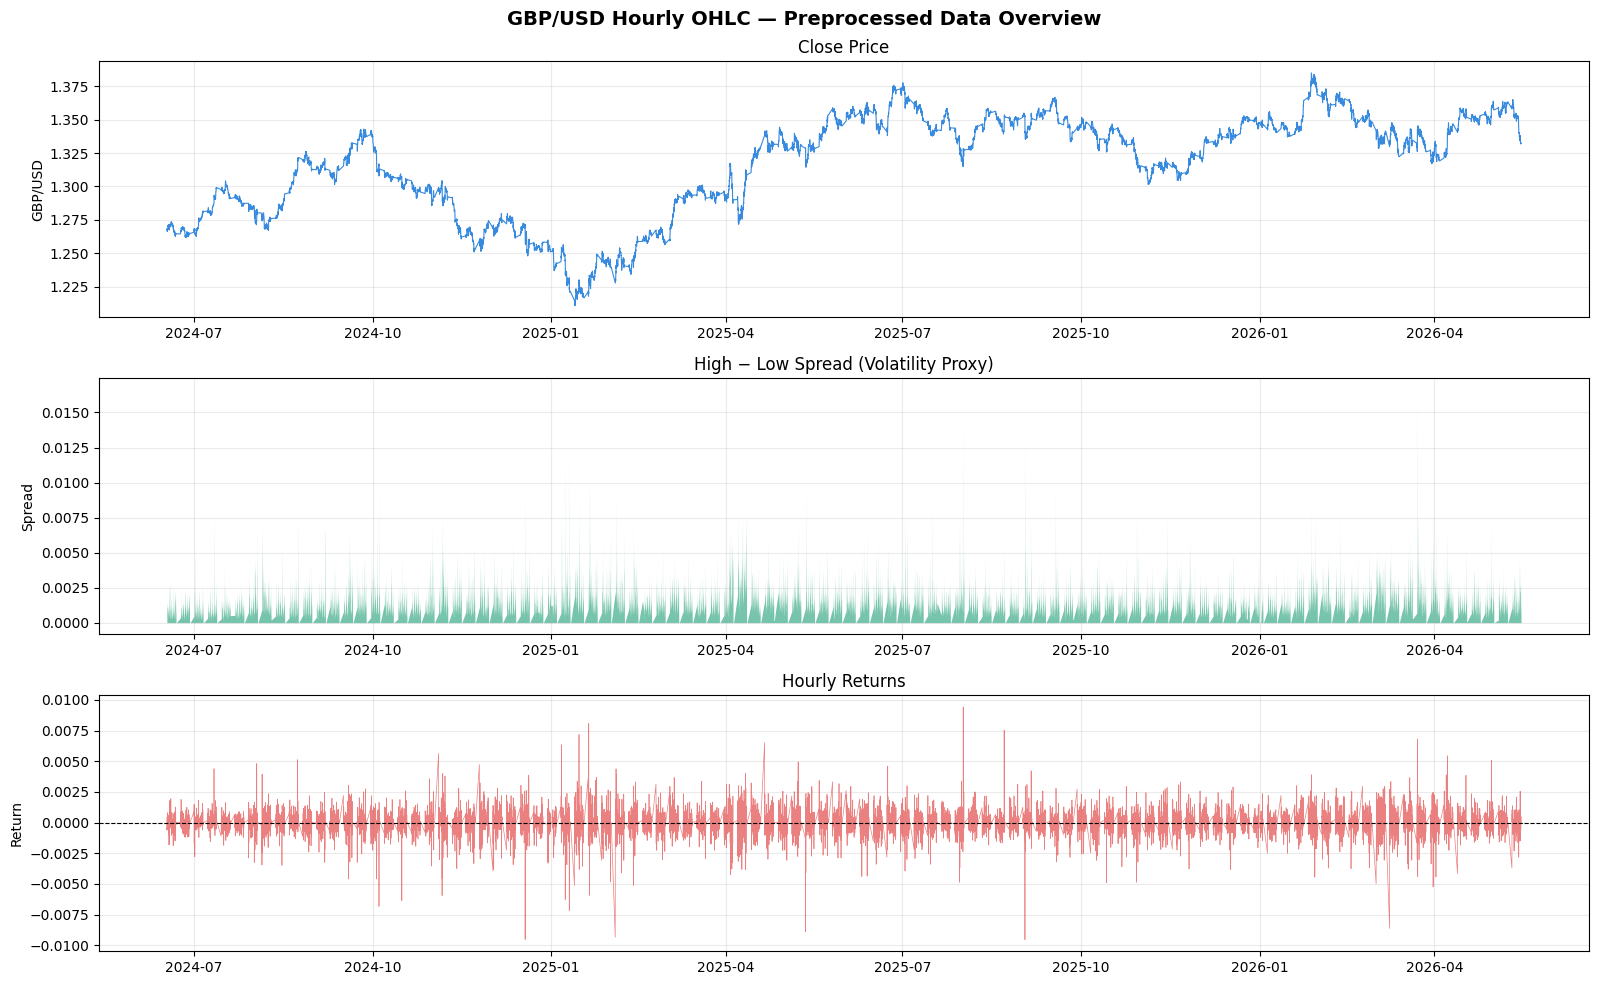

  Saved  →  plots/00_data_overview.png


In [15]:
print("\n[STEP 3]  Plotting raw data overview ...")

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle("GBP/USD Hourly OHLC — Preprocessed Data Overview",
             fontsize=14, fontweight="bold")

# Close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=0.8)
axes[0].set_title("Close Price")
axes[0].set_ylabel("GBP/USD")
axes[0].grid(True, alpha=0.25)

# High - Low spread
axes[1].fill_between(df.index,
                     df["High"] - df["Low"],
                     color="#1D9E75", alpha=0.6, linewidth=0)
axes[1].set_title("High − Low Spread (Volatility Proxy)")
axes[1].set_ylabel("Spread")
axes[1].grid(True, alpha=0.25)

# Hourly returns
ret = df["Close"].pct_change().dropna()
axes[2].plot(df.index[1:], ret, color="#E24B4A", linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Hourly Returns")
axes[2].set_ylabel("Return")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00_data_overview.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Feature engineering**


[STEP 4]  Feature engineering ...
  Features (12): ['Open', 'High', 'Low', 'Close', 'returns', 'hl_spread', 'oc_spread', 'sma_10', 'sma_24', 'ema_12', 'momentum', 'volatility']
  Rows after feature engineering : 11,971


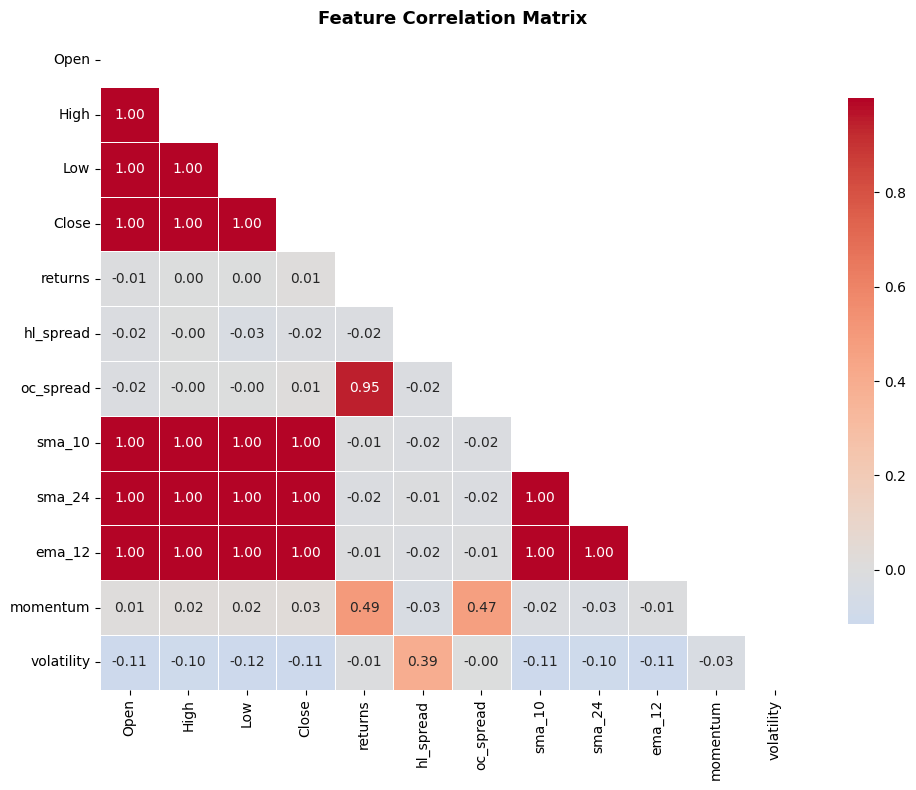

  Saved  →  plots/00b_correlation_matrix.png


In [16]:
print("\n[STEP 4]  Feature engineering ...")

fe = df.copy()

# Candle structure
fe["returns"]     = fe["Close"].pct_change()                         # hourly % return
fe["hl_spread"]   = fe["High"]  - fe["Low"]                         # High-Low range
fe["oc_spread"]   = fe["Close"] - fe["Open"]                        # Open-Close delta

# Trend indicators
fe["sma_10"]      = fe["Close"].rolling(10).mean()                   # 10-period SMA
fe["sma_24"]      = fe["Close"].rolling(24).mean()                   # 24-period SMA (≈ 1 day)
fe["ema_12"]      = fe["Close"].ewm(span=12, adjust=False).mean()   # Exponential MA

# Momentum
fe["momentum"]    = fe["Close"] - fe["Close"].shift(4)              # 4-hour momentum

# Volatility proxy
fe["volatility"]  = fe["returns"].rolling(12).std()                 # 12-hr rolling std

# Drop any NaN rows introduced by rolling / shift
fe.dropna(inplace=True)

FEATURES  = [
    "Open", "High", "Low", "Close",
    "returns", "hl_spread", "oc_spread",
    "sma_10", "sma_24", "ema_12",
    "momentum", "volatility",
]
CLOSE_IDX = FEATURES.index("Close")   # position of target in scaled array

print(f"  Features ({len(FEATURES)}): {FEATURES}")
print(f"  Rows after feature engineering : {len(fe):,}")

# Feature correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = fe[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00b_correlation_matrix.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Normalize features**

In [17]:
print("\n[STEP 5]  Normalising features with MinMaxScaler [0, 1] ...")

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(fe[FEATURES].values)

print(f"  Scaled array shape : {scaled.shape}")
print(f"  Min after scaling  : {scaled.min():.4f}  (should be 0.0)")
print(f"  Max after scaling  : {scaled.max():.4f}  (should be 1.0)")


[STEP 5]  Normalising features with MinMaxScaler [0, 1] ...
  Scaled array shape : (11971, 12)
  Min after scaling  : 0.0000  (should be 0.0)
  Max after scaling  : 1.0000  (should be 1.0)


**SEQUENCE CREATION  (sliding window — lookback = 24 hours)**

In [18]:
def create_sequences(data: np.ndarray, lookback: int, target_idx: int):
    """
    Build (X, y) pairs with a sliding window.

    For each position i from lookback to end:
      X[i] = data[i-lookback : i]     shape → (lookback, n_features)
      y[i] = data[i, target_idx]      shape → scalar  (next Close, scaled)

    The window slides one step at a time, so every hour produces one sample.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i])    # input: past 24 hours
        y.append(data[i, target_idx])       # target: next hour Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print(f"\n[STEP 6]  Creating sequences (lookback = {LOOKBACK} hours) ...")

X, y = create_sequences(scaled, LOOKBACK, CLOSE_IDX)
print(f"  X shape : {X.shape}   →  (samples, timesteps, features)")
print(f"  y shape : {y.shape}   →  (samples,)")


[STEP 6]  Creating sequences (lookback = 24 hours) ...
  X shape : (11947, 24, 12)   →  (samples, timesteps, features)
  y shape : (11947,)   →  (samples,)


**Train / Validation / Test split**

In [19]:
print("\n[STEP 7]  Splitting data (no shuffle — time-series) ...")

n       = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

print(f"  Total sequences : {n:,}")
print(f"  Train   70 %    : {X_train.shape[0]:,} samples")
print(f"  Val     15 %    : {X_val.shape[0]:,} samples")
print(f"  Test    15 %    : {X_test.shape[0]:,} samples")

INPUT_SHAPE = (LOOKBACK, len(FEATURES))   # (24, 12)


[STEP 7]  Splitting data (no shuffle — time-series) ...
  Total sequences : 11,947
  Train   70 %    : 8,362 samples
  Val     15 %    : 1,792 samples
  Test    15 %    : 1,793 samples


# **MODEL**

**Vanilla RNN**

In [20]:
def build_rnn(input_shape, units, dropout, lr):
    """
    Vanilla (Simple) RNN — two stacked SimpleRNN layers.
    Known limitation: suffers from vanishing gradient on long sequences.
    """
    model = Sequential(name="Vanilla_RNN")
    model.add(SimpleRNN(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(SimpleRNN(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    return model

**LSTM**

In [21]:
def build_lstm(input_shape, units, dropout, lr):
    """
    Stacked LSTM — Long Short-Term Memory.
    Input, forget, and output gates mitigate the vanishing gradient problem.
    """
    model = Sequential(name="LSTM")
    model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    return model

**GRU**

In [22]:
def build_gru(input_shape, units, dropout, lr):
    """
    Stacked GRU — Gated Recurrent Unit.
    Simpler than LSTM (reset + update gates only); often trains faster
    with comparable accuracy.
    """
    model = Sequential(name="GRU")
    model.add(GRU(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(GRU(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    return model

**BiLSTM**

In [23]:
def build_bilstm(input_shape, units, dropout, lr):
    """
    Bidirectional LSTM — wraps LSTM to read the sequence both
    forward and backward, doubling contextual representation.
    Second layer uses units // 2 to keep parameter count comparable.
    """
    model = Sequential(name="BiLSTM")
    model.add(Bidirectional(
        LSTM(units, return_sequences=True),
        input_shape=input_shape
    ))
    model.add(Dropout(dropout))
    model.add(Bidirectional(
        LSTM(units // 2, return_sequences=False)
    ))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    return model

**TRAINING FUNCTION**

In [26]:
def train_model(model, X_tr, y_tr, X_v, y_v):
    """
    Train one model independently with three callbacks:

    EarlyStopping      — stops if val_loss does not improve for PATIENCE epochs
                         and restores the best weights automatically.
    ReduceLROnPlateau  — halves the learning rate when val_loss stagnates
                         for 7 consecutive epochs (floor: 1e-6).
    ModelCheckpoint    — saves the best weights to disk during training.
    """
    name      = model.name
    ckpt_path = os.path.join(MODELS_DIR, f"{name}_best.weights.h5")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=0,
        ),
        ModelCheckpoint(
            ckpt_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=True,
            verbose=0,
        ),
    ]

    print(f"\n  {'─'*60}")
    print(f"  Training [{name}]  —  {model.count_params():,} parameters")
    print(f"  {'─'*60}")

    t_start = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1,
    )
    elapsed    = time.time() - t_start
    best_epoch = int(np.argmin(history.history["val_loss"])) + 1
    best_loss  = float(min(history.history["val_loss"]))

    print(f"\n  [{name}] Finished  |  "
          f"Best epoch: {best_epoch}  |  "
          f"Best val_loss: {best_loss:.6f}  |  "
          f"Time: {elapsed:.1f}s")
    return history, elapsed



**EVALUATION FUNCTION**

In [25]:
# def inverse_close(scaled_vals: np.ndarray) -> np.ndarray:
#     """
#     Inverse-transform only the Close column from scaled space back to price.

#     MinMaxScaler was fitted on all 12 features together, so we must rebuild
#     a full-width dummy array, place the scaled Close values in the correct
#     column, invert, and extract that column.
#     """
#     dummy = np.zeros((len(scaled_vals), len(FEATURES)))
#     dummy[:, CLOSE_IDX] = scaled_vals
#     return scaler.inverse_transform(dummy)[:, CLOSE_IDX]


# def evaluate_model(model, X_te, y_te):
#     """
#     Compute four metrics on the test set:
#       RMSE  — Root Mean Squared Error          (lower is better)
#       MAE   — Mean Absolute Error              (lower is better)
#       MAPE  — Mean Absolute Percentage Error   (lower is better)
#       DA    — Direction Accuracy               (higher is better)
#                = % of hourly up/down moves correctly predicted
#     """
#     preds_sc = model.predict(X_te, verbose=0).flatten()
#     preds    = inverse_close(preds_sc)
#     actual   = inverse_close(y_te)

#     rmse = float(np.sqrt(mean_squared_error(actual, preds)))
#     mae  = float(mean_absolute_error(actual, preds))
#     mape = float(np.mean(np.abs((actual - preds) / (actual + 1e-9))) * 100)
#     da   = float(np.mean(
#         np.sign(np.diff(actual)) == np.sign(np.diff(preds))
#     ) * 100)

#     return preds, actual, {"RMSE": rmse, "MAE": mae, "MAPE": mape, "DA (%)": da}



**BUILD, TRAIN & EVALUATE ALL MODELS**

In [30]:
print("\n\n" + "=" * 70)
print("  PHASE A — Training All Models Independently")
print("=" * 70)

models_config = [
    ("RNN",    build_rnn),
    ("LSTM",   build_lstm),
    ("GRU",    build_gru),
    ("BiLSTM", build_bilstm),
]

results = {}

for model_name, builder in models_config:
    # Fresh model — no shared weights between experiments
    model = builder(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
    history, elapsed = train_model(model, X_train, y_train, X_val, y_val)
    # preds, actual, metrics = evaluate_model(model, X_test, y_test)

    results[model_name] = {
        "model":   model,
        "history": history,
        # "preds":   preds,
        # "actual":  actual,
        # "metrics": metrics,
        "params":  model.count_params(),
        "time":    elapsed,
    }



  PHASE A — Training All Models Independently

  ────────────────────────────────────────────────────────────
  Training [Vanilla_RNN]  —  15,297 parameters
  ────────────────────────────────────────────────────────────
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0321 - mae: 0.1257 - val_loss: 0.0013 - val_mae: 0.0270 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0069 - mae: 0.0650 - val_loss: 0.0040 - val_mae: 0.0591 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0044 - mae: 0.0517 - val_loss: 0.0013 - val_mae: 0.0260 - learning_rate: 0.0010
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0032 - mae: 0.0441 - val_loss: 0.0016 - val_mae: 0.0335 - learning_rate: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - mae: 0.0400 - val_loss: 0.0017 - val_mae: 0.0346 - learning_rate: 0.0010
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0023

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


131/131 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0080 - mae: 0.0590 - val_loss: 0.0022 - val_mae: 0.0414 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - loss: 0.0020 - mae: 0.0345 - val_loss: 0.0018 - val_mae: 0.0375 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0016 - mae: 0.0302 - val_loss: 0.0025 - val_mae: 0.0464 - learning_rate: 0.0010
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0012 - mae: 0.0261 - val_loss: 0.0022 - val_mae: 0.0435 - learning_rate: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0011 - mae: 0.0251 - val_loss: 0.0035 - val_mae: 0.0561 - learning_rate: 0.0010
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 8.9900e-04 - mae: 0.0227 - val_loss: 0.0038 - val_mae: 0.0580 - learning_rate: 0.0010
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 7.1503e-04 - mae: 0.0202 - val_loss: 0.0059 - val_mae: 0.0746 - learning_rate: 0.0010
Ep

**RESULTS TABLE**

In [38]:
print("\n\n" + "=" * 70)
print("  PHASE B — Evaluation Results")
print("=" * 70)

rows = []
for name, r in results.items():
    m = r["metrics"]
    rows.append({
        "Model":    name,
        "RMSE":     round(m["RMSE"],    5),
        "MAE":      round(m["MAE"],     5),
        "MAPE (%)": round(m["MAPE"],    3),
        "DA (%)":   round(m["DA (%)"],  2),
        "Params":   r["params"],
        "Time (s)": round(r["time"],    1),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print("\n" + results_df.to_string())
results_df.to_csv(os.path.join(PLOTS_DIR, "model_comparison.csv"))
print(f"\n  Results table saved  →  {PLOTS_DIR}/model_comparison.csv")

,RMSE,MAE,MAPE,DA (%)


**VISUALISATIONS**

In [ ]:
print("\n\n" + "=" * 70)
print("  PHASE C — Generating Plots")
print("=" * 70)

COLORS = {
    "RNN":    "#E24B4A",
    "LSTM":   "#378ADD",
    "GRU":    "#1D9E75",
    "BiLSTM": "#BA7517",
}
MODEL_NAMES = list(results.keys())

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
})
 # ── Figure 1 : Training & Validation Loss Curves ─────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle("Training & Validation Loss (MSE) — All Models",
             fontsize=14, fontweight="bold", y=1.02)

for ax, name in zip(axes, MODEL_NAMES):
    h   = results[name]["history"].history
    eps = range(1, len(h["loss"]) + 1)
    ax.plot(eps, h["loss"],     label="Train", color=COLORS[name], linewidth=2)
    ax.plot(eps, h["val_loss"], label="Val",   color=COLORS[name],
            linewidth=2, linestyle="--", alpha=0.7)
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "01_loss_curves.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 2 : All-model Overlay on Test Set ─────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(actual, color="black", linewidth=1.5, label="Actual GBP/USD", zorder=5)
for name in MODEL_NAMES:
    ax.plot(results[name]["preds"], color=COLORS[name],
            linewidth=1.1, alpha=0.8, label=name)
ax.set_title("GBP/USD Hourly — Actual vs All Predictions (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time Steps (hours)")
ax.set_ylabel("GBP/USD Price")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
path = os.path.join(PLOTS_DIR, "02_predictions_overlay.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 3 : Individual 2×2 Prediction Subplots ───────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Individual Model Predictions vs Actual (Test Set)",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

for ax, name in zip(axes, MODEL_NAMES):
    m = results[name]["metrics"]
    ax.plot(actual,                 color="black",      linewidth=1.4,
            label="Actual", alpha=0.9)
    ax.plot(results[name]["preds"], color=COLORS[name], linewidth=1.2,
            label=name, alpha=0.85)
    subtitle = (f"RMSE={m['RMSE']:.5f}  |  MAE={m['MAE']:.5f}  |  "
                f"MAPE={m['MAPE']:.2f}%  |  DA={m['DA (%)']:.1f}%")
    ax.set_title(f"{name}\n{subtitle}", fontsize=10,
                 color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Hours")
    ax.set_ylabel("Price")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "03_individual_predictions.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 4 : Scatter — Actual vs Predicted ─────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Scatter: Actual vs Predicted Prices (Test Set)",
             fontsize=14, fontweight="bold")

for ax, name in zip(axes, MODEL_NAMES):
    p  = results[name]["preds"]
    a  = results[name]["actual"]
    ax.scatter(a, p, s=5, alpha=0.3, color=COLORS[name])
    lo = min(a.min(), p.min())
    hi = max(a.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="Perfect fit")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "04_scatter.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 5 : Metrics Bar Charts ────────────────────────────────────────────
display_metrics = [
    ("RMSE",   "RMSE"),
    ("MAE",    "MAE"),
    ("MAPE",   "MAPE (%)"),
    ("DA (%)", "Direction Accuracy (%)"),
]
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Model Performance Metric Comparison",
             fontsize=14, fontweight="bold")

for ax, (key, label) in zip(axes, display_metrics):
    values = [results[n]["metrics"][key] for n in MODEL_NAMES]
    bars   = ax.bar(MODEL_NAMES, values,
                    color=[COLORS[n] for n in MODEL_NAMES],
                    width=0.5, edgecolor="white")
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "05_metrics_comparison.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 6 : Residual Distributions ────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Residual Distribution (Predicted − Actual)",
             fontsize=14, fontweight="bold")

for ax, name in zip(axes, MODEL_NAMES):
    residuals = results[name]["preds"] - results[name]["actual"]
    ax.hist(residuals, bins=50, color=COLORS[name], alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Residual (Price)")
    ax.set_ylabel("Frequency")
    ax.grid(True, alpha=0.2)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "06_residuals.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")


# ── Figure 7 : Model Complexity ──────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Model Complexity Comparison", fontsize=14, fontweight="bold")

times  = [results[n]["time"]   for n in MODEL_NAMES]
params = [results[n]["params"] for n in MODEL_NAMES]

for ax, values, ylabel in [
    (ax1, times,  "Seconds"),
    (ax2, params, "Parameters"),
]:
    bars = ax.bar(MODEL_NAMES, values,
                  color=[COLORS[n] for n in MODEL_NAMES], width=0.5)
    ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)

ax1.set_title("Training Time (seconds)")
ax2.set_title("Total Trainable Parameters")

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "07_complexity.png")
plt.savefig(path, bbox_inches="tight")
plt.show()
print(f"  Saved  →  {path}")

**Final Summary**

In [ ]:
print("\n\n" + "=" * 70)
print("  FINAL COMPARISON SUMMARY")
print("=" * 70)
print(results_df.to_string())

best_rmse = results_df["RMSE"].idxmin()
best_mape = results_df["MAPE (%)"].idxmin()
best_da   = results_df["DA (%)"].idxmax()
fastest   = results_df["Time (s)"].idxmin()

print(f"\n  Best RMSE             → {best_rmse:<8} ({results_df.loc[best_rmse, 'RMSE']:.5f})")
print(f"  Best MAPE             → {best_mape:<8} ({results_df.loc[best_mape, 'MAPE (%)']:.3f}%)")
print(f"  Best Direction Acc    → {best_da:<8} ({results_df.loc[best_da, 'DA (%)']:.2f}%)")
print(f"  Fastest Training      → {fastest:<8} ({results_df.loc[fastest, 'Time (s)']:.1f}s)")
print(f"\n  Plots saved  →  ./{PLOTS_DIR}/   (8 files)")
print(f"  Weights saved→  ./{MODELS_DIR}/   (4 files)")
print("\n" + "=" * 70)
print("  All done.")
print("=" * 70)